# 08 · Logistic Regression & Classification

**Difficulty:** Intermediate | **Time:** ~3 hours

Classification = predicting a **category** (spam/not-spam, disease/healthy, fraud/legit).

## Table of Contents
1. Classification vs Regression
2. Logistic Regression Theory
3. Binary Classification: Spam Detection
4. Evaluation Metrics Deep Dive
5. Confusion Matrix & ROC Curve
6. Multiclass Classification
7. Real-World Project: Credit Default Prediction

## 1. Classification Types

| Type | Examples | Output |
|---|---|---|
| Binary | Spam/Ham, Fraud/Legit | 0 or 1 |
| Multiclass | Digit 0-9, Species | One of N classes |
| Multilabel | Tags on a photo | Multiple classes |

**Logistic Regression** despite its name is a **classification** algorithm.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, roc_auc_score,
                              classification_report)
import warnings
warnings.filterwarnings('ignore')
print("Ready ✓")

Ready ✓


## 2. The Sigmoid Function — Core of Logistic Regression

$$P(y=1|x) = \sigma(z) = \frac{1}{1+e^{-z}}, \quad z = \beta_0 + \beta_1 x$$

Output is always between 0 and 1 — a **probability**.

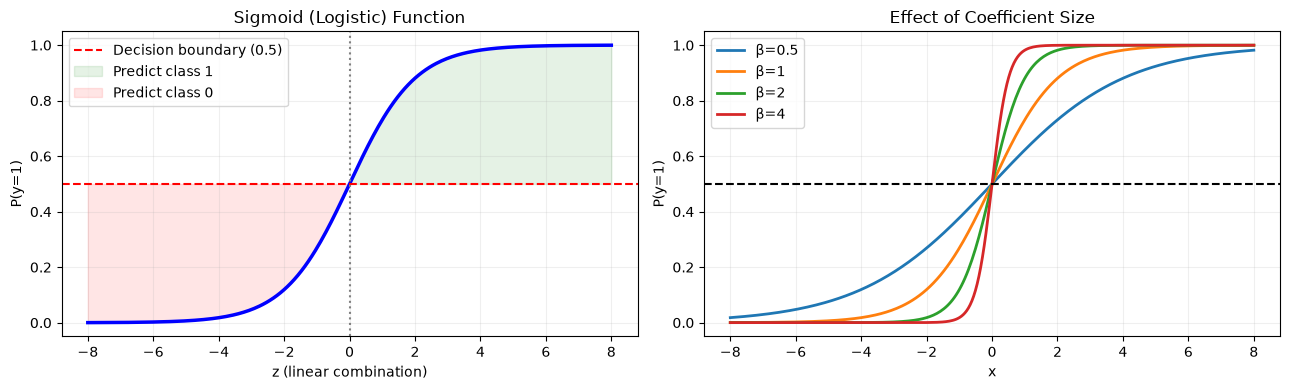

In [2]:
# Visualize the sigmoid
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

z = np.linspace(-8, 8, 300)
sigmoid = 1 / (1 + np.exp(-z))

axes[0].plot(z, sigmoid, 'b-', linewidth=2.5)
axes[0].axhline(0.5, color='red', linestyle='--', label='Decision boundary (0.5)')
axes[0].axvline(0, color='gray', linestyle=':')
axes[0].fill_between(z, sigmoid, 0.5, where=(z > 0), alpha=0.1, color='green', label='Predict class 1')
axes[0].fill_between(z, sigmoid, 0.5, where=(z < 0), alpha=0.1, color='red', label='Predict class 0')
axes[0].set_xlabel("z (linear combination)"); axes[0].set_ylabel("P(y=1)")
axes[0].set_title("Sigmoid (Logistic) Function"); axes[0].legend(); axes[0].grid(alpha=0.2)

# Show how different β values affect the curve
betas = [0.5, 1, 2, 4]
for beta in betas:
    axes[1].plot(z, 1/(1+np.exp(-beta*z)), linewidth=2, label=f'β={beta}')
axes[1].axhline(0.5, color='black', linestyle='--')
axes[1].set_title("Effect of Coefficient Size"); axes[1].legend()
axes[1].set_xlabel("x"); axes[1].set_ylabel("P(y=1)"); axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig("/tmp/sigmoid.png", dpi=100)
plt.show()

## 3. Binary Classification: Email Spam Detection

In [3]:
# Simulate email dataset
np.random.seed(42)
n = 1000

# Spam features: lots of exclamation marks, links, capital words, short emails
# Ham features: normal word counts, longer emails

is_spam = np.random.choice([0, 1], n, p=[0.65, 0.35])

data = pd.DataFrame({
    'exclamation_count': np.where(is_spam, np.random.poisson(8,n), np.random.poisson(1,n)),
    'link_count'       : np.where(is_spam, np.random.poisson(5,n), np.random.poisson(1,n)),
    'capitals_ratio'   : np.where(is_spam, np.random.uniform(0.3,0.9,n), np.random.uniform(0,0.2,n)),
    'word_count'       : np.where(is_spam, np.random.randint(10,100,n), np.random.randint(50,500,n)),
    'is_spam': is_spam
})

print("Dataset shape:", data.shape)
print("\nSpam vs Ham:")
print(data['is_spam'].value_counts().rename({0:'Ham',1:'Spam'}))
print(f"\nSpam rate: {data['is_spam'].mean():.1%}")

Dataset shape: (1000, 5)

Spam vs Ham:
is_spam
Ham     671
Spam    329
Name: count, dtype: int64

Spam rate: 32.9%


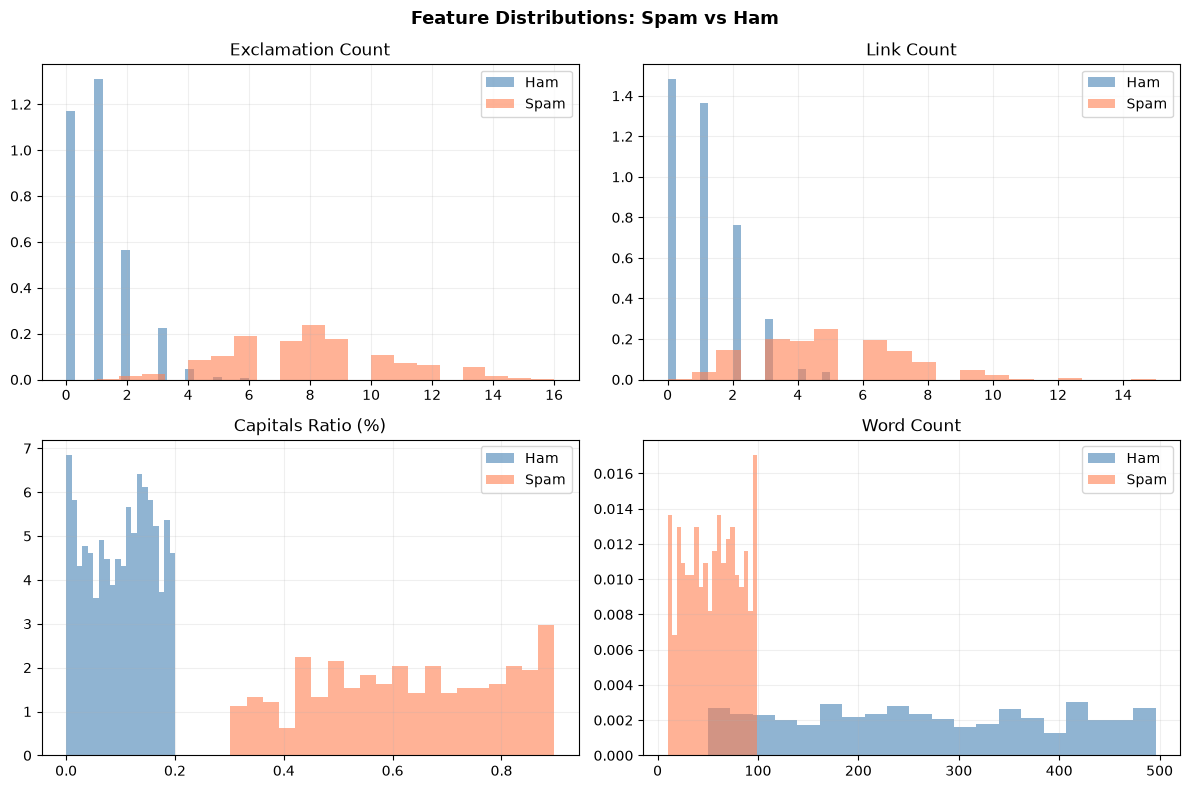

In [4]:
# Visualize feature differences between spam and ham
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['exclamation_count','link_count','capitals_ratio','word_count']
titles   = ['Exclamation Count','Link Count','Capitals Ratio (%)','Word Count']

for ax, feat, title in zip(axes.ravel(), features, titles):
    ham_data  = data[data['is_spam']==0][feat]
    spam_data = data[data['is_spam']==1][feat]
    
    bins = 20
    ax.hist(ham_data,  bins=bins, alpha=0.6, color='steelblue', label='Ham',  density=True)
    ax.hist(spam_data, bins=bins, alpha=0.6, color='coral',     label='Spam', density=True)
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.2)

plt.suptitle("Feature Distributions: Spam vs Ham", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/spam_features.png", dpi=100)
plt.show()

In [5]:
# Train Logistic Regression
X = data.drop('is_spam', axis=1)
y = data['is_spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

clf = LogisticRegression(random_state=42)
clf.fit(X_train_s, y_train)

y_pred      = clf.predict(X_test_s)
y_pred_prob = clf.predict_proba(X_test_s)[:, 1]  # P(spam)

print("Model trained ✓")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.2%}")
print(f"Precision: {precision_score(y_test, y_pred):.2%}")
print(f"Recall   : {recall_score(y_test, y_pred):.2%}")
print(f"F1 Score : {f1_score(y_test, y_pred):.2%}")

Model trained ✓

Accuracy: 100.00%
Precision: 100.00%
Recall   : 100.00%
F1 Score : 100.00%


## 4. Evaluation Metrics — Know the Difference

```
              PREDICTED
              0 (Ham)  1 (Spam)
ACTUAL  0    TN        FP   ← False alarm (annoys user)
        1    FN        TP   ← Missed spam (dangerous!)
```

- **Accuracy** = (TP+TN)/Total — misleading with imbalanced data
- **Precision** = TP/(TP+FP) — of all predicted spam, how many were really spam?
- **Recall** = TP/(TP+FN) — of all actual spam, how many did we catch?
- **F1** = harmonic mean of Precision & Recall

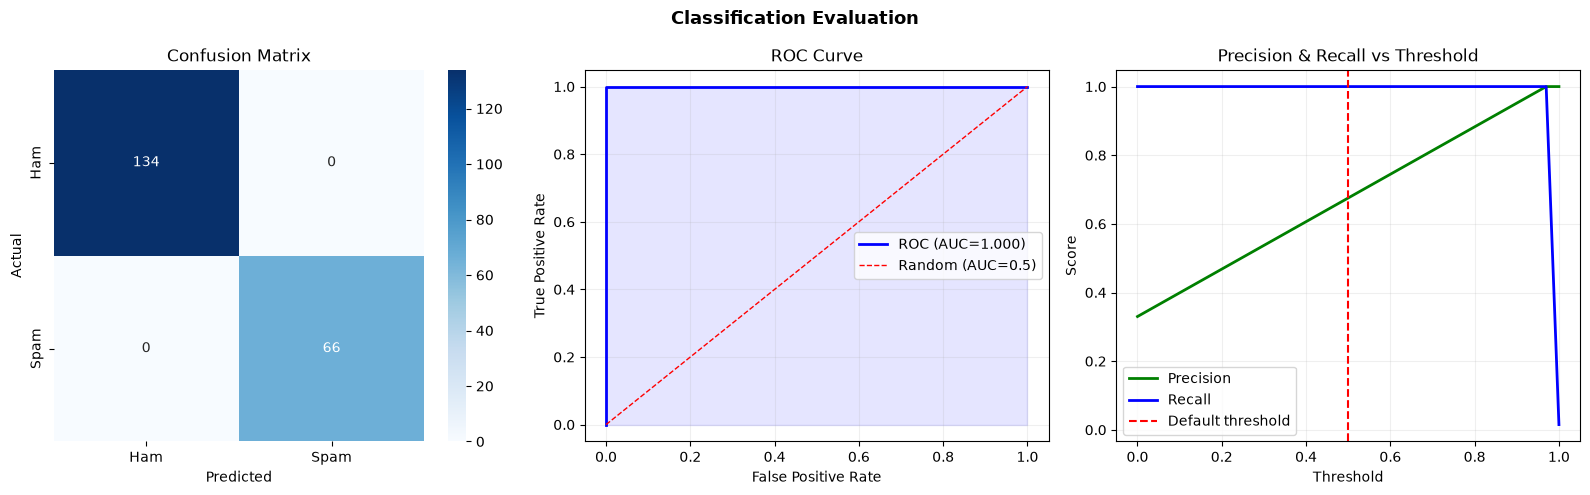

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1], 'r--', linewidth=1, label='Random (AUC=0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='blue')
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve"); axes[1].legend(); axes[1].grid(alpha=0.2)

# Precision-Recall vs Threshold
prec_arr = [precision_score(y_test, y_pred_prob>=t, zero_division=0) for t in thresholds]
rec_arr  = [recall_score(y_test, y_pred_prob>=t) for t in thresholds]
axes[2].plot(thresholds, prec_arr, 'g-', label='Precision', linewidth=2)
axes[2].plot(thresholds, rec_arr,  'b-', label='Recall',    linewidth=2)
axes[2].axvline(0.5, color='red', linestyle='--', label='Default threshold')
axes[2].set_xlabel("Threshold"); axes[2].set_ylabel("Score")
axes[2].set_title("Precision & Recall vs Threshold"); axes[2].legend(); axes[2].grid(alpha=0.2)

plt.suptitle("Classification Evaluation", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/tmp/clf_evaluation.png", dpi=100)
plt.show()

## 5. When to Adjust the Threshold

In [7]:
# Default threshold = 0.5. But you can tune it!
# Medical diagnosis: prefer HIGH RECALL (catch all sick patients, even some false alarms)
# Spam filter: prefer HIGH PRECISION (don't block good emails)

threshs = [0.3, 0.5, 0.7]
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<10} {'F1':<10}")
print("-" * 44)
for t in threshs:
    pred_t = (y_pred_prob >= t).astype(int)
    p = precision_score(y_test, pred_t, zero_division=0)
    r = recall_score(y_test, pred_t)
    f = f1_score(y_test, pred_t)
    note = ""
    if t == 0.3: note = " ← High Recall"
    if t == 0.5: note = " ← Default"
    if t == 0.7: note = " ← High Precision"
    print(f"{t:<12.1f} {p:<12.2%} {r:<10.2%} {f:<10.2%}{note}")

Threshold    Precision    Recall     F1        
--------------------------------------------
0.3          100.00%      100.00%    100.00%    ← High Recall
0.5          100.00%      100.00%    100.00%    ← Default
0.7          100.00%      100.00%    100.00%    ← High Precision


## 6. Multiclass Classification — Iris Flowers

In [8]:
from sklearn.datasets import load_iris
from sklearn.metrics import ConfusionMatrixDisplay

iris = load_iris()
X_iris, y_iris = iris.data, iris.target
feature_names = iris.feature_names
class_names   = iris.target_names

X_tr, X_te, y_tr, y_te = train_test_split(X_iris, y_iris, test_size=0.25, 
                                            random_state=42, stratify=y_iris)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

clf_multi = LogisticRegression(max_iter=1000)
clf_multi.fit(X_tr_s, y_tr)
y_pred_iris = clf_multi.predict(X_te_s)

print(classification_report(y_te, y_pred_iris, target_names=class_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



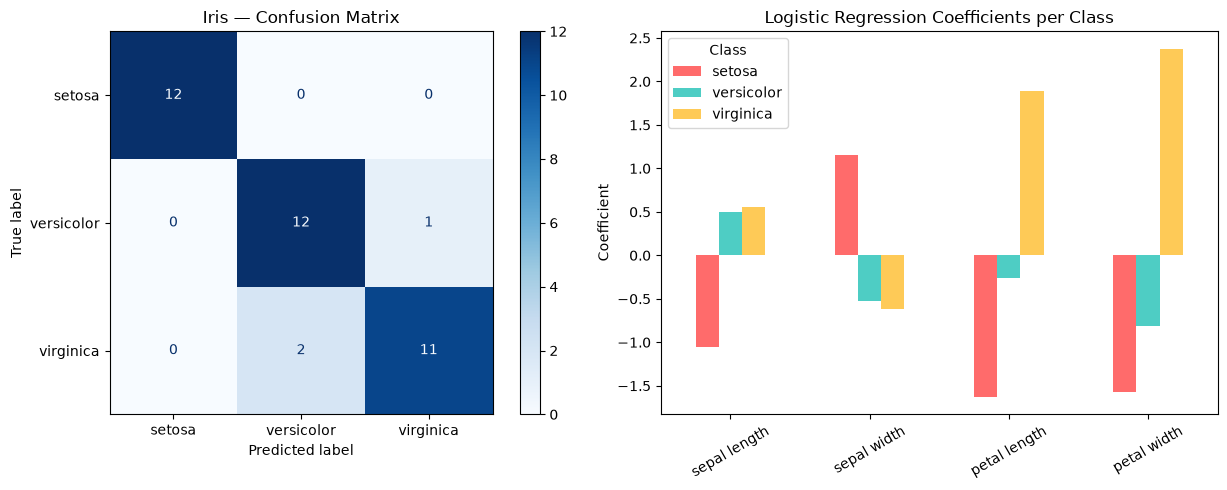

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred_iris),
                       display_labels=class_names).plot(ax=axes[0], cmap='Blues')
axes[0].set_title("Iris — Confusion Matrix")

# Feature importance (coefficients)
coef_df = pd.DataFrame(clf_multi.coef_.T, 
                        index=[f.replace(' (cm)','') for f in feature_names],
                        columns=class_names)
coef_df.plot(kind='bar', ax=axes[1], color=['#FF6B6B','#4ECDC4','#FECA57'])
axes[1].set_title("Logistic Regression Coefficients per Class")
axes[1].set_ylabel("Coefficient"); axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Class')

plt.tight_layout()
plt.savefig("/tmp/iris_clf.png", dpi=100)
plt.show()

## 7. Real-World Project: Credit Default Prediction

In [10]:
# Credit scoring dataset
np.random.seed(42)
n = 2000

credit = pd.DataFrame({
    'credit_score'   : np.random.randint(300, 850, n),
    'annual_income'  : np.random.randint(20000, 200000, n),
    'loan_amount'    : np.random.randint(5000, 100000, n),
    'loan_term_months': np.random.choice([12,24,36,48,60], n),
    'num_late_payments': np.random.poisson(1, n).clip(0, 10),
    'debt_to_income' : np.random.uniform(0.1, 0.8, n),
    'employment_years': np.random.randint(0, 30, n),
})
# Probability of default based on features
prob_default = (
    0.6
    - credit['credit_score'] / 1700
    - credit['annual_income'] / 500000
    + credit['loan_amount'] / 200000
    + credit['num_late_payments'] * 0.08
    + credit['debt_to_income'] * 0.4
    - credit['employment_years'] * 0.01
)
prob_default = 1 / (1 + np.exp(-prob_default * 4))
credit['defaulted'] = (np.random.random(n) < prob_default).astype(int)

print(f"Default rate: {credit['defaulted'].mean():.1%}")
print(credit.head())

Default rate: 79.5%
   credit_score  annual_income  loan_amount  loan_term_months  \
0           402         180878        64197                60   
1           735         108199        63847                24   
2           570          61321        16577                12   
3           406         173728        82299                12   
4           371          75147        25176                60   

   num_late_payments  debt_to_income  employment_years  defaulted  
0                  0        0.535838                 1          1  
1                  0        0.556932                18          0  
2                  4        0.638577                 5          1  
3                  0        0.209697                 9          1  
4                  2        0.619062                 8          1  


Credit Default Model Performance:
              precision    recall  f1-score   support

  No Default       0.35      0.73      0.47        82
     Default       0.90      0.65      0.75       318

    accuracy                           0.67       400
   macro avg       0.63      0.69      0.61       400
weighted avg       0.79      0.67      0.70       400

AUC-ROC: 0.743


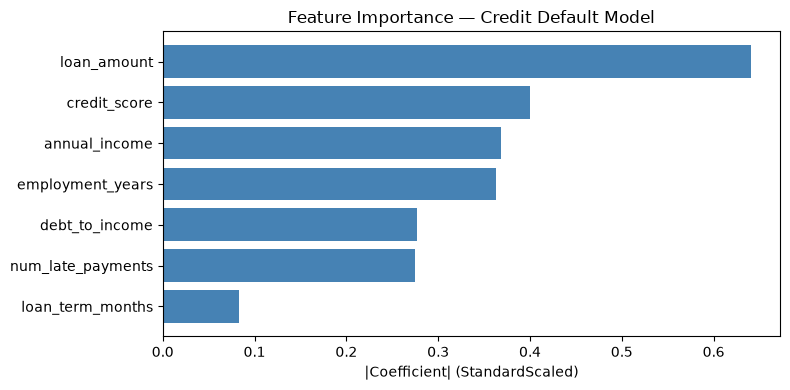

In [11]:
X_c = credit.drop('defaulted', axis=1)
y_c = credit['defaulted']

X_tr, X_te, y_tr, y_te = train_test_split(X_c, y_c, test_size=0.2, 
                                            random_state=42, stratify=y_c)
sc = StandardScaler()
clf_credit = LogisticRegression(class_weight='balanced', max_iter=1000)
clf_credit.fit(sc.fit_transform(X_tr), y_tr)

y_pred_c = clf_credit.predict(sc.transform(X_te))
y_prob_c = clf_credit.predict_proba(sc.transform(X_te))[:,1]

print("Credit Default Model Performance:")
print(classification_report(y_te, y_pred_c, target_names=['No Default','Default']))
print(f"AUC-ROC: {roc_auc_score(y_te, y_prob_c):.3f}")

# Feature importance
coef_imp = pd.DataFrame({'Feature':X_c.columns, 'Importance':np.abs(clf_credit.coef_[0])})
coef_imp = coef_imp.sort_values('Importance', ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(coef_imp['Feature'], coef_imp['Importance'], color='steelblue')
ax.set_title("Feature Importance — Credit Default Model")
ax.set_xlabel("|Coefficient| (StandardScaled)")
plt.tight_layout()
plt.savefig("/tmp/credit_importance.png", dpi=100)
plt.show()

## Summary

| Metric | When to Prioritize |
|---|---|
| Accuracy | Balanced classes |
| Precision | Cost of false alarms is high |
| Recall | Cost of missing positives is high |
| F1 Score | Imbalanced classes, balanced trade-off |
| AUC-ROC | Compare models across thresholds |

**Key insight:** Always use `class_weight='balanced'` or SMOTE when classes are imbalanced.

**Next notebook →** `09_Decision_Trees.ipynb`